# Hyperuniformity (point distribution version)

___

Hyperuniform systems (periodic or disordered) anomalously suppress density fluctuations at large length scales compared to the garden variety disordered systems, such as fluids. 

A point distribution is hyperuniform if the local number variance $\sigma^2(R) = \left< N^2(R)\right> − \left< N(R)\right>^2$ of the number of points $N(R)$ found in a spherical window of radius $R$ grows slower than $R^d$ in the large-R limit [[1]](https://arxiv.org/pdf/1801.06924).

Equivalently, in the reciprocal space, a hyperuniform state for point distributions is characterized by a structure factor that vanishes in the infinite-wavelength limit, i.e., $\lim_{q\rightarrow 0} S(q) = 0$. Often, $S(q)$ takes the radial power-law form in the vicinity of the origin, i.e., $S(q) \propto q^\alpha$, where $\alpha$ is a positive exponent. The value of $\alpha$ determines strength of the hyperuniformity.

$$
\sigma^2(R) \sim
\begin{cases}
R^{d-1}, & \alpha > 1 \quad (\text{class I}), \\
R^{d-1}\ln R, & \alpha = 1 \quad (\text{class II}), \\
R^{d-\alpha}, & 0 < \alpha < 1 \quad (\text{class III}).
\end{cases}
$$


The degree of hyperuniformity can also be quantified using the $H$ metric given as:

$$ H = \frac{S(\textbf{0})}{S(q_{max})}$$

Smaller the value of $H$, more hyperuniform the system is. Since numerically, we cannot compute $S(\textbf{0})$ because this will require a `BoxSize` that is infinite, we rather use a curve-fitting to extrapolate the value at $S(0)$. For simplicity, we use a linear fit. 

In this notebook, we shall create some processes of each kind and evaluate their hyperuniformity class. Since the structure factor for these processes are analytic, we could use `tostada.Optimization` to inverse design a distribution with the prescribed $S(q)$. 


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tostada as tost

GPU detected. Using CUDA.
GPU detected. Using CUDA.
Using MPI version 4.1, 1 processes
GPU detected. Using CUDA
Using JAX devices: [CudaDevice(id=0)]


E0608 16:11:59.601379 1180448 cuda_context.cc:141] The primary context is active and has a different flag set (128) than the desired flag set (0).


Let us first create a Ginibre point distribution. The structure factor for it is given by $S(q) = 1 - \exp{(-a^2q^2/(2\pi)^2)}$. Such a distribution is class I hyperuniform and the system behaves like a highly structured liquid or a crystal at long wavelengths, rather than a random gas [[2]](https://doi.org/10.1063/5.0189769). 

In [2]:
process = tost.Pointprocess(BoxSize=6, # size of the box along x,y. Currently assumes z=0
                            diameter=0, # let us choose diameter=0 for an unconstrained optimization. However, one can choose any d < ax
                            ax = 0.25 # mean particle distance
                            )

Now, one can run the `.ginibre()` method available in `tostada.Pointprocess` to create the point distribution. 
Please note : at the moment, we only create a distribution using the structure factor in the low-$q$ limit and so the pair-correlation trends may not be faithfully represented.

In [3]:
points = process.ginibre()

choosing qmax = 150.79644737231007 and q_f = 25.132741228718345
Initial state undefined. Choosing random sequential adsorption process.
Estimated particles to be deposited=576 with mean inter-particle distance=0.25
number of experiments:3611000): |------------------------------| 0.4% Current FF=15.972 of 16.000


/home/prerak/miniconda3/envs/tost/lib/python3.12/site-packages/numpy/_core/getlimits.py:559: UserWarning: The value of the smallest subnormal for <class 'numpy.float32'> type is zero.
  setattr(self, word, getattr(machar, word).flat[0])
/home/prerak/miniconda3/envs/tost/lib/python3.12/site-packages/numpy/_core/getlimits.py:91: UserWarning: The value of the smallest subnormal for <class 'numpy.float32'> type is zero.
  return self._float_to_str(self.smallest_subnormal)


Current iteration : 5, Objective = 0.011798541992902756 with gradient = 0.9167149066925049
Current iteration : 10, Objective = 0.004198941867798567 with gradient = 0.28393006324768066
Current iteration : 15, Objective = 0.0028799246065318584 with gradient = 0.14444074034690857
Current iteration : 20, Objective = 0.002365340478718281 with gradient = 0.12328588962554932
Current iteration : 25, Objective = 0.002126087201759219 with gradient = 0.07942567765712738
Current iteration : 30, Objective = 0.0019789317157119513 with gradient = 0.06213412061333656
Current iteration : 35, Objective = 0.001883493852801621 with gradient = 0.048034533858299255
Current iteration : 40, Objective = 0.0018050011713057756 with gradient = 0.03882574662566185
Current iteration : 45, Objective = 0.0017507311422377825 with gradient = 0.041202791035175323
Current iteration : 50, Objective = 0.0017017883947119117 with gradient = 0.034512974321842194
Current iteration : 55, Objective = 0.0016602020477876067 with g

Let us compare the obtained $S(q)$ against the analytical solution. This is accesible in `tostada.Statistics` along with some other analytical models for $S(q)$.

In [6]:
from tostada.Statistics import Sq_analytic
Sq = points.ReciprocalSpace(kmax=100)
q = points.Sq_averaged[:,0]
Sq_fit = Sq_analytic(q,dmean=points.dmean,option='ginibre',param=None)

Let us visualize this state using `tostada.Visualize`

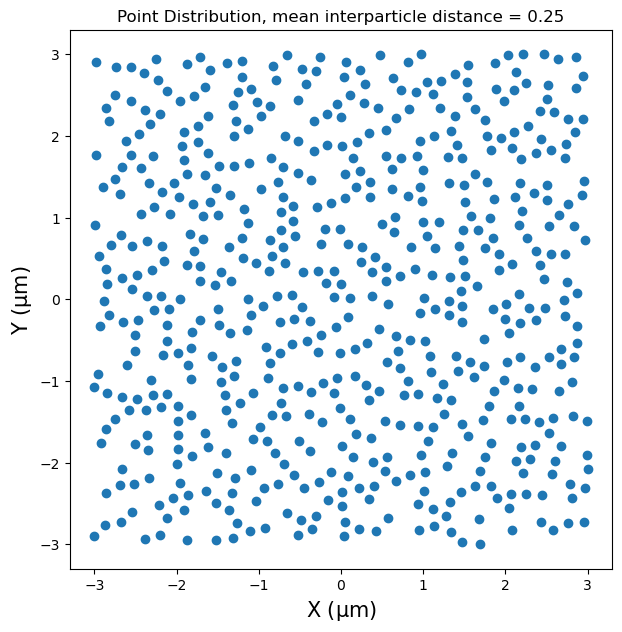

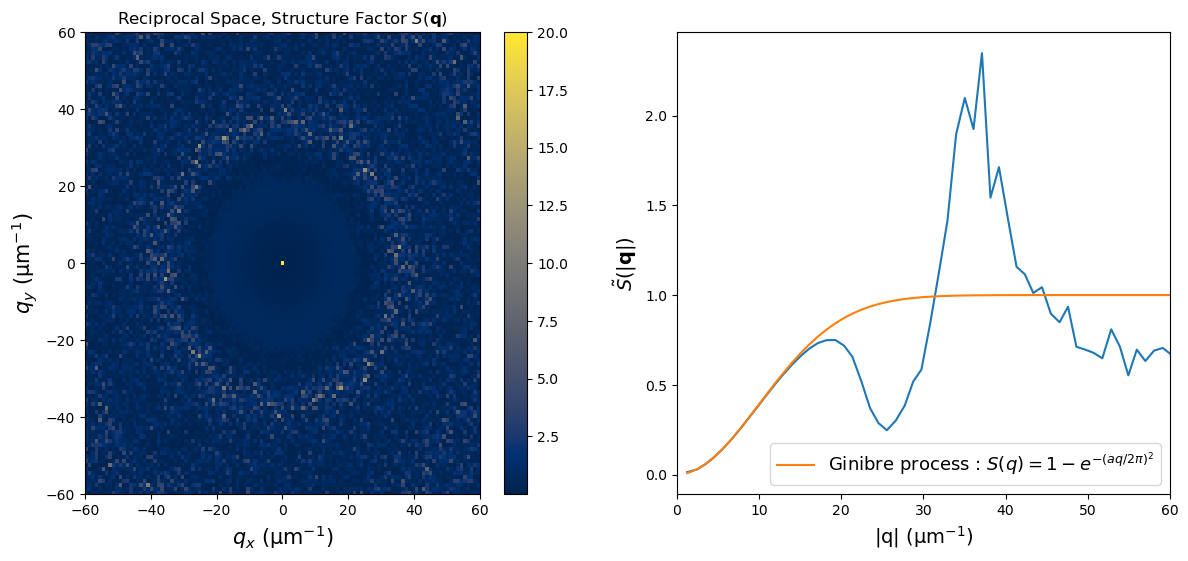

In [ ]:
fig = tost.Visualize(points)
fig.plot_distribution()
ax=fig.plot_reciprocal_space()
ax[1].plot(q,Sq_fit,label='Ginibre process : $S(q) = 1-e^{-(aq/2\\pi)^2}$')

plt.legend(fontsize=13)


Let us evaluate the hyperuniformity properties of this distribution. 

In [19]:
fwhm, h_index, b , alpha = points.Hyperuniformity_data(hud_class=True)
print ('alpha of the hyperuniformity is, alpha={a}'.format(a=alpha))

Spectral Width of the structural peak=7.331245352442451
Hyperuniformity of the structure = 4.685677001158056e-10
HUD class with alpha=1.9635186639632942
alpha of the hyperuniformity is, alpha=1.9635186639632942


the value of $\alpha$ is close to its theoretical value of $\alpha=2$. For a larger box size or more particles, this value should approach $\alpha=2$. One can assess the validity of this curve-fit by extracting the fitting parameters using `fit_param` option.

In [10]:
fwhm, h_index, beta, alpha = points.Hyperuniformity_data(hud_class=True,fit_param=True)

fit parameters for linear trend = [1.80121561e-02 1.10020328e-09]
fit parameters for class trend = [0.00496524 1.96351866]
Spectral Width of the structural peak=7.331245352442451
Hyperuniformity of the structure = 4.685677001158056e-10
HUD class with alpha=1.9635186639632942


This yields two fitting parameter set. First is the fit for the linear trend for obtaining $S(0)$. Second is a polynomial fit with a function $S(q) = bq^{\alpha}$ in the $q\rightarrow 0$ limit.

(0.0, 1.0)

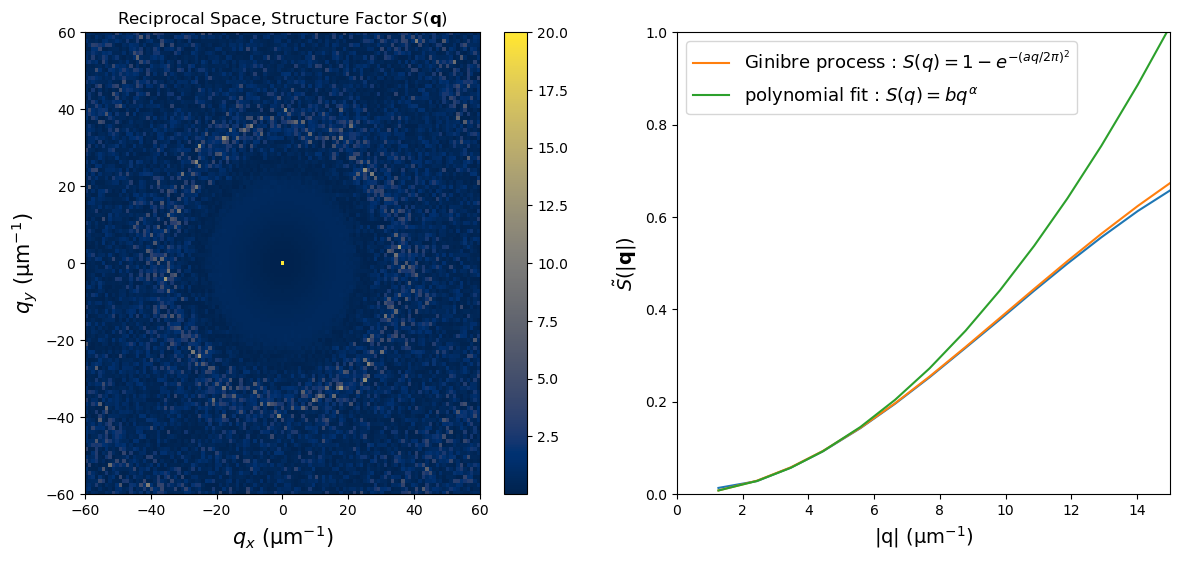

In [18]:
ax=fig.plot_reciprocal_space()
ax[1].plot(q,Sq_fit,label='Ginibre process : $S(q) = 1-e^{-(aq/2\\pi)^2}$')
ax[1].plot(q,lam*q**alpha,label='polynomial fit : $S(q) = bq^{\\alpha}$')

plt.legend(fontsize=13)
ax[1].set_xlim(0,15)
ax[1].set_ylim(0,1)

___

Let us now create a distribution with $alpha=1$. We choose the fourier dual of a one-component plasma whose structure factor is given as $S(q) = 1 - \exp{(-aq/\pi)}$ [[3]](https://doi.org/10.1103/PhysRevE.101.032124).

It is also possible to choose a different diameter. Let us choose $d = 0.5a$.

In [23]:
process = tost.Pointprocess(BoxSize=6, # size of the box along x,y. Currently assumes z=0
                            diameter=0.125, # let us choose diameter=0 for an unconstrained optimization. However, one can choose any d < ax
                            ax = 0.25 # mean particle distance
                            )
points2 = process.fourier_dual_ocp()

choosing qmax = 150.79644737231007 and q_f = 25.132741228718345
Initial state undefined. Choosing random sequential adsorption process.
Estimated particles to be deposited=576 with mean inter-particle distance=0.25
number of experiments:3969000): |------------------------------| 0.4% Current FF=15.972 of 16.000
Current iteration : 5, Objective = 0.11667605489492416 with gradient = 12.525644302368164
Current iteration : 10, Objective = 0.011851204559206963 with gradient = 0.9897794723510742
Current iteration : 15, Objective = 0.00569324754178524 with gradient = 0.3674570918083191
Current iteration : 20, Objective = 0.004018392413854599 with gradient = 0.17439091205596924
Current iteration : 25, Objective = 0.0033841519616544247 with gradient = 0.13481906056404114
Current iteration : 30, Objective = 0.0031000159215182066 with gradient = 0.1566680371761322
Current iteration : 35, Objective = 0.002885232213884592 with gradient = 0.09326730668544769
Current iteration : 40, Objective = 0.002

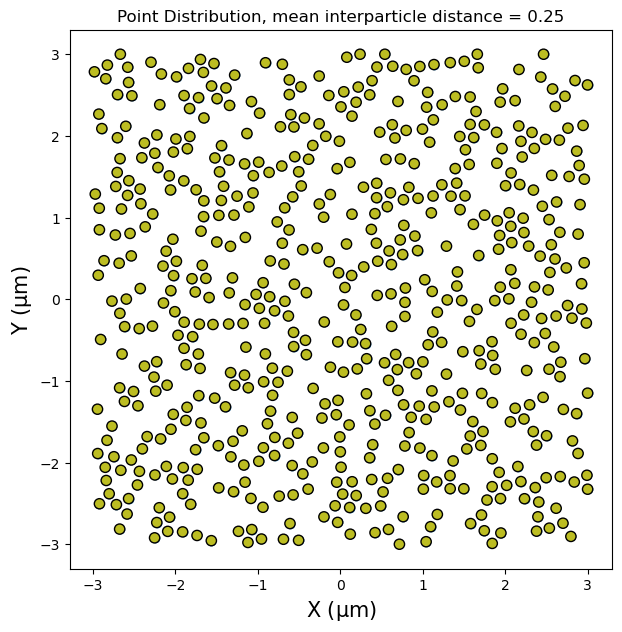

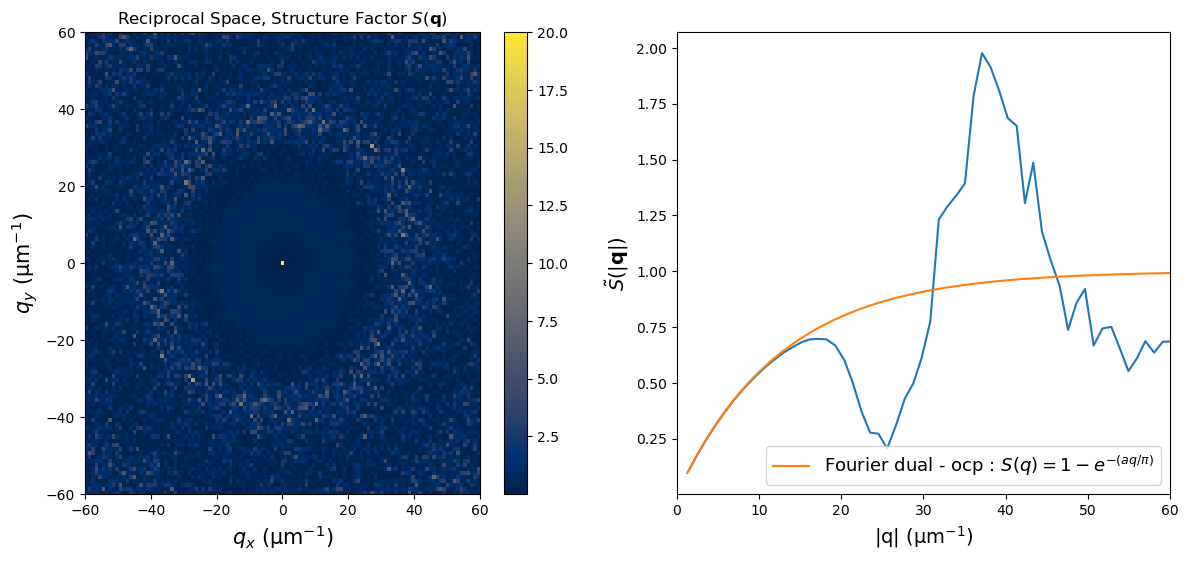

In [24]:
fig = tost.Visualize(points2)
fig.plot_distribution()
ax=fig.plot_reciprocal_space()
Sq_fit = Sq_analytic(q,dmean=points.dmean,option='fourier_dual_ocp',param=None)
ax[1].plot(q,Sq_fit,label='Fourier dual - ocp : $S(q) = 1-e^{-(aq/\\pi)}$')
plt.legend(fontsize=13)

From the structure factor, one can already identify such a distribution to be less hyperuniform than the first case ($\alpha=1$).

In [27]:
fwhm, H, b, alpha = points2.Hyperuniformity_data(hud_class=True,
                                                 pad=0 # Optional. pads the first m pixels in [q,Sq]. Useful for experimental images and Sq 
                                                 )

Spectral Width of the structural peak=5.12977409362793
Hyperuniformity of the structure = 0.007187618687098097
HUD class with alpha=0.8951659496458204


___

We now look at the cases where the distributions are non-hyperuniform. That is, $\alpha < 1$.

First is a Hermite Gaussian distribution with structure factor given by: $S(q) = 1-\lambda \sqrt{2} (-4 (aq)^4 + 12(aq)^2 - 3)e^{-(aq)^2/2}$ [[2]](https://doi.org/10.1063/5.0189769). 

Since these distributions are obtained through a local gradient optimizer, these can be sensitive to the initial point distribution. It is also possible to provide a `tostada.PointDistribution` as the initial state and this is used for the optimization. This is done using the `init_state` option.

If not provided, tostada creates a quick default distribution and uses it for optimization as it did till now.

In [ ]:
process = tost.Pointprocess(BoxSize=6, # size of the box along x,y. Currently assumes z=0
                            diameter=0, # let us choose diameter=0 for an unconstrained optimization. However, one can choose any d < ax
                            ax = 0.25 # mean particle distance
                            ) 

initial_point_distribution = process.poisson()
points3 = process.hermite_gaussian(
                                    maxiter=100,
                                    init_state = initial_point_distribution
                                    )

choosing qmax = 150.79644737231007 and q_f = 25.132741228718345
Current iteration : 5, Objective = 0.18837253749370575 with gradient = 6.731786727905273
Current iteration : 10, Objective = 0.03426237776875496 with gradient = 3.3297581672668457
Current iteration : 15, Objective = 0.013079417869448662 with gradient = 0.7091560363769531
Current iteration : 20, Objective = 0.009180533699691296 with gradient = 0.37058210372924805
Current iteration : 25, Objective = 0.007753388956189156 with gradient = 0.2864082455635071
Current iteration : 30, Objective = 0.007006367202848196 with gradient = 0.37657538056373596
Current iteration : 35, Objective = 0.0065778507851064205 with gradient = 0.17029818892478943
Current iteration : 40, Objective = 0.0063002509996294975 with gradient = 0.11880147457122803
Current iteration : 45, Objective = 0.006099809892475605 with gradient = 0.11892370134592056
Current iteration : 50, Objective = 0.005917011294513941 with gradient = 0.17249885201454163
Current iter

In [20]:
Sq_fit = Sq_analytic(q,dmean=points3.dmean,option='hermite_gaussian',param=1/15)

(0.0, 30.0)

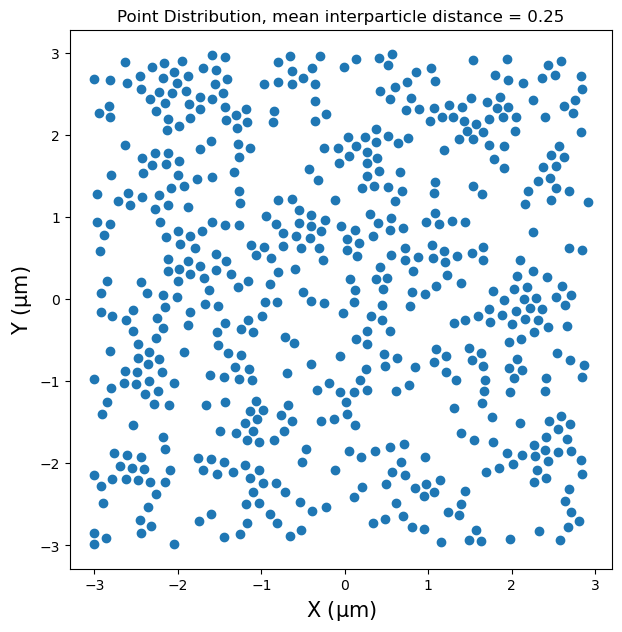

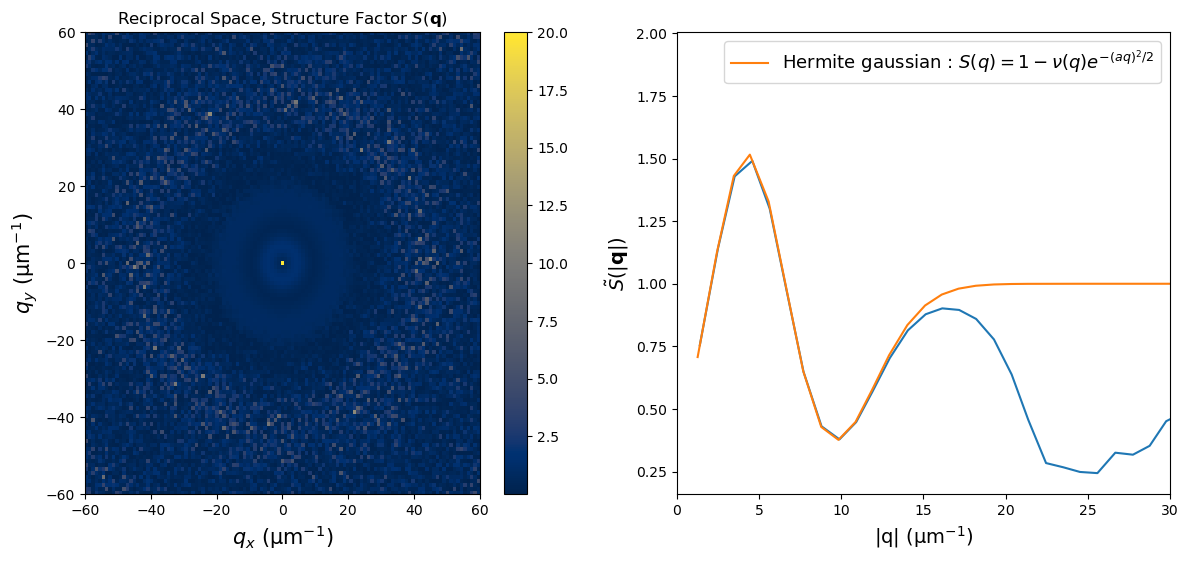

In [21]:
fig = tost.Visualize(points3)
fig.plot_distribution()
ax=fig.plot_reciprocal_space()
ax[1].plot(q,Sq_fit,label='Hermite gaussian : $S(q) = 1-\\nu(q)e^{-(aq)^2/2}$')
plt.legend(fontsize=13)
ax[1].set_xlim(0,30)

In [37]:
points3.Hyperuniformity_data(hud_class=True)

Spectral Width of the structural peak=18.872137214102835
Hyperuniformity of the structure = 0.3712870652682823
HUD class with alpha=0.4892615703041105


array([18.87213721,  0.37128707,  0.74215049,  0.48926157])

___

It is also possible to create an anti-hyperuniform distribution ($\alpha<0$) using `tostada.Optimization`. Here, the structure factor does not approach zero for $q\rightarrow 0$. We choose a structure factor given by $S(q) = 1 + 1/(aq)$.

In [38]:
points4 = process.anti_hyperuniform()

choosing qmax = 150.79644737231007 and q_f = 25.132741228718345
Initial state undefined. Choosing random sequential adsorption process.
Estimated particles to be deposited=576 with mean inter-particle distance=0.25
number of experiments:4185000): |------------------------------| 0.4% Current FF=15.972 of 16.000
Current iteration : 5, Objective = 1.6673824787139893 with gradient = 22.4209041595459
Current iteration : 10, Objective = 0.6193962693214417 with gradient = 12.288041114807129
Current iteration : 15, Objective = 0.23753367364406586 with gradient = 7.18580961227417
Current iteration : 20, Objective = 0.11473554372787476 with gradient = 4.058289051055908
Current iteration : 25, Objective = 0.07099150121212006 with gradient = 2.874972343444824
Current iteration : 30, Objective = 0.03428170084953308 with gradient = 1.6394062042236328
Current iteration : 35, Objective = 0.025743650272488594 with gradient = 0.9585716724395752
Current iteration : 40, Objective = 0.022405661642551422 w

In [39]:
Sq_fit = Sq_analytic(q,dmean=points3.dmean,option='anti_hud',param=None)

(0.0, 5.0)

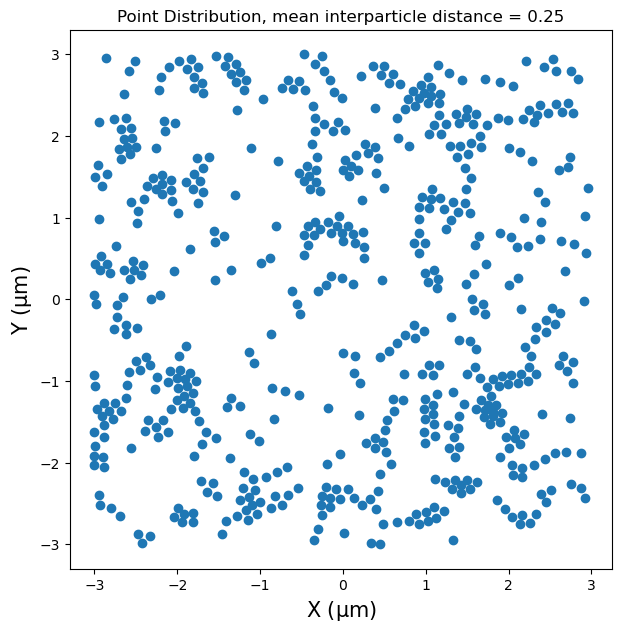

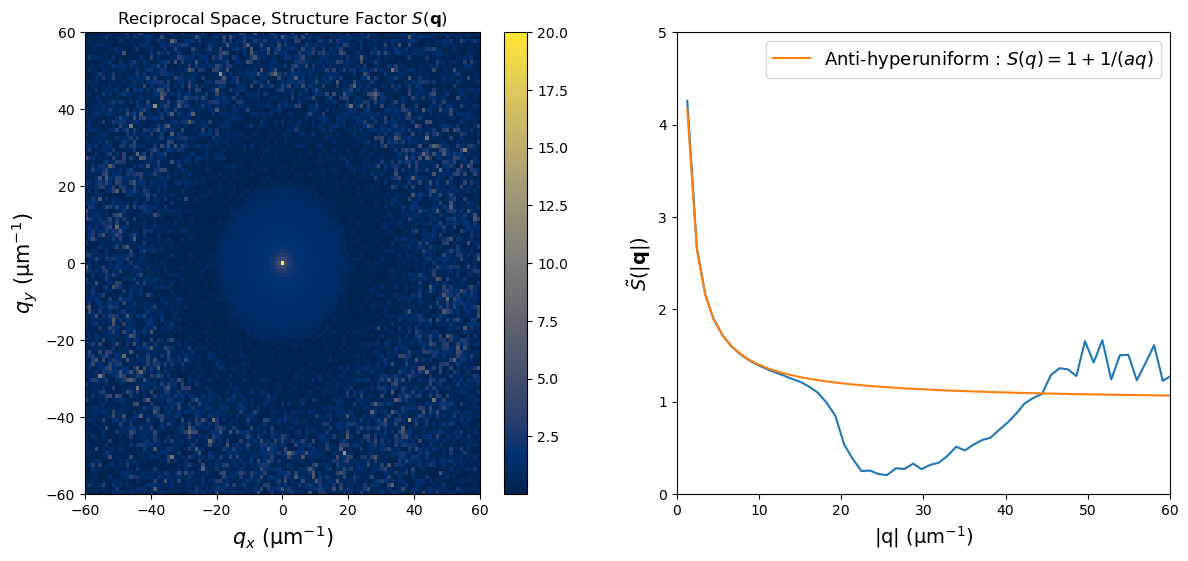

In [63]:
fig = tost.Visualize(points4)
fig.plot_distribution()
ax=fig.plot_reciprocal_space()
ax[1].plot(q,Sq_fit,label='Anti-hyperuniform : $S(q) = 1+1/(aq)$')

plt.legend(fontsize=13)
ax[1].set_ylim(0,5)

Anti-hyperuniform systems can also be generated using a hyperplane intersection algorithm. The distribution consists of points that lie on intersecting and randomly oriented lines inside the box. The structure factor for such a distribution also diverges at $q\rightarrow 0$.

Such a distribution can also be generated from `tostada.Pointprocess`. Please note : the number of points inside the box are not guranteed by the `Pointprocess.estimated_particles` and change each time.

In [ ]:
points5 = process.hyperplane_intersection()

(0.0, 5.0)

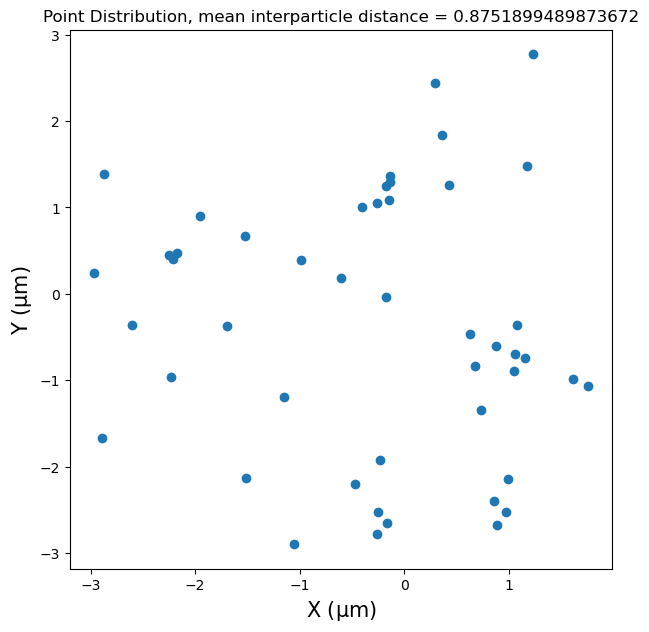

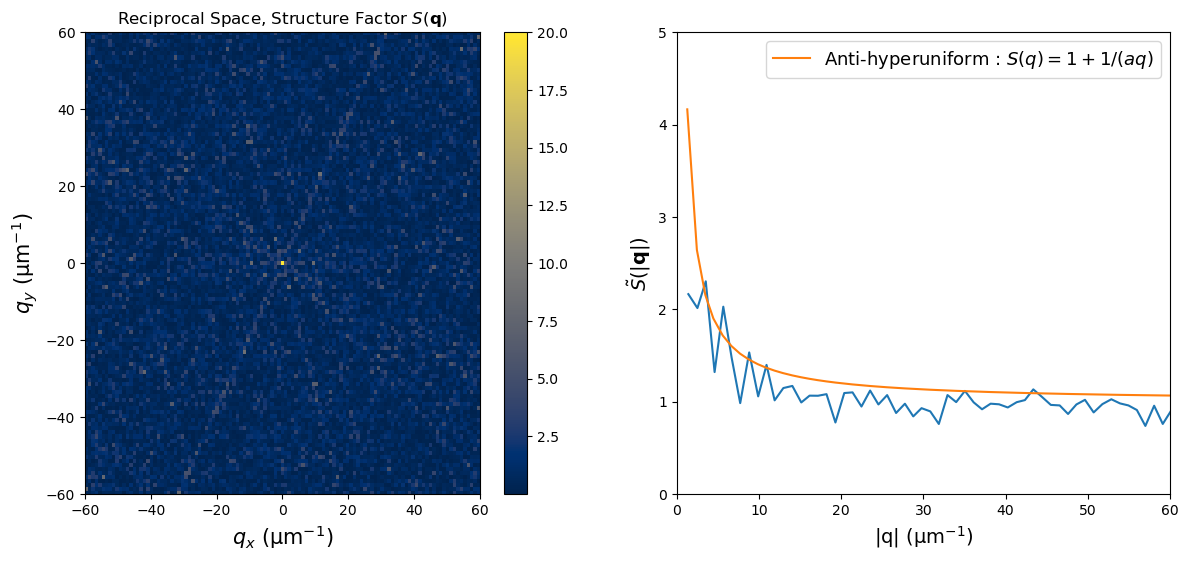

In [72]:
fig = tost.Visualize(points5)
fig.plot_distribution()
ax=fig.plot_reciprocal_space()
ax[1].plot(q,Sq_fit,label='Anti-hyperuniform : $S(q) = 1+1/(aq)$')
plt.legend(fontsize=13)
ax[1].set_ylim(0,5)